# CH 4 單變數圖表（Univariate Plots）

單變數圖表用來呈現單一變數的分佈、頻率、比例、極值等特性。常見的單變數圖表包括：長條圖（Bar Chart）、直方圖（Histogram）、圓餅圖（Pie Chart）、箱型圖（Box Plot）。

## 4.1 長條圖（Bar Plot）

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH4_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH4_dataset/images'

Mounted at /content/drive


In [ ]:
# # Define the path for images and dataset folds
# path = '/content/drive/MyDrive/Teaching/大數據視覺化設計實務/Handout/CH04/'

### 1. 定義
長條圖以矩形條的長度（或高度）來呈現不同類別變數的數值大小，通常用於分類資料的比較與分佈展示。

### 2. 範例圖表與說明

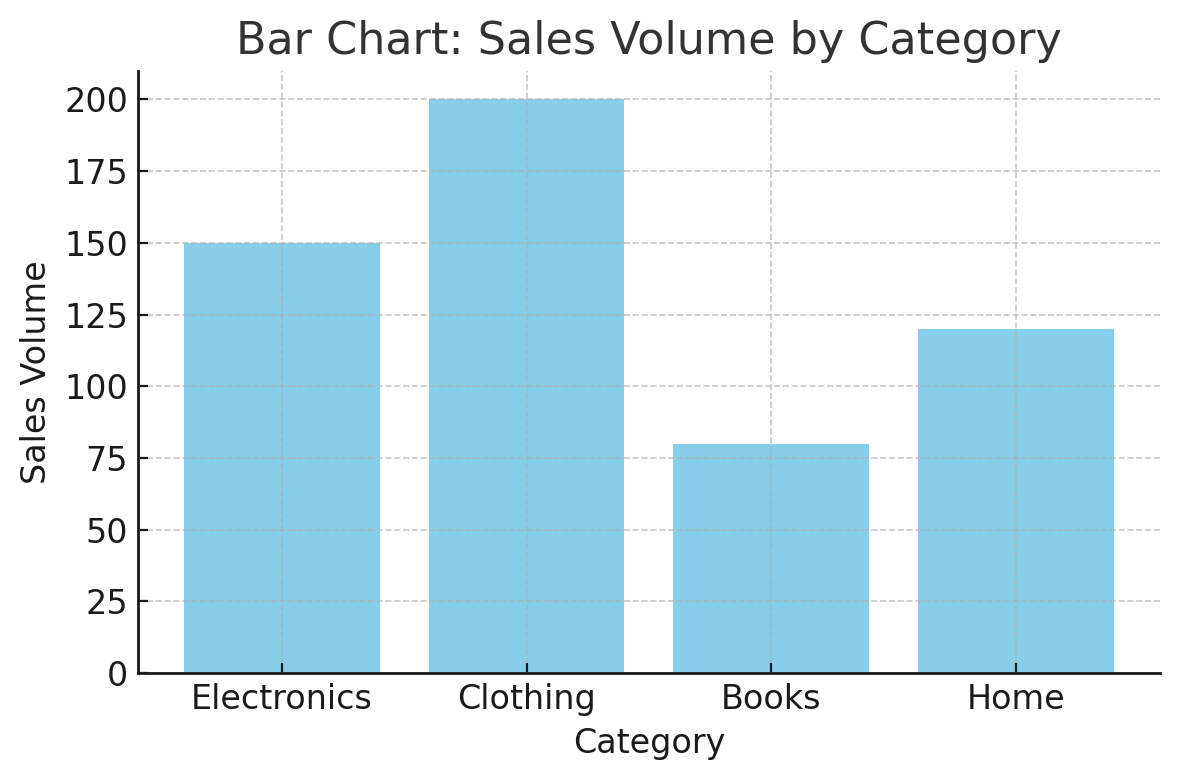

In [ ]:
from IPython import display
display.Image(img_path +"/"+ 'Bar-00.png', width = 500)

**觀察與解釋**：  
圖表顯示不同商品類別的銷售數量。Clothing 類別最高（200 件），Books 最低（80 件），清楚顯示各分類之間的差距，有助於進行熱銷品類分析與行銷資源分配。


### Try it!：2. 範例圖表與說明
門診管理室想快速看出各科別一週的門診量高低。

**程式要求**
1. 讀取 `datasets/weekly_outpatients_by_department.csv`。
2. 依 `Weekly_Patients` 由高到低排序並印出統計表。
3. 繪製長條圖，並在每個長條上方標示數值。

### 3. 適用情況
- 類別型資料的數量比較  
- 需要強調不同分類間差異  
- 適用於名目資料或序列資料


### 4. 優缺點
- **優點**：  
  - 易於理解，視覺清楚  
  - 支援分類多樣且可堆疊/群組顯示  
- **缺點**：  
  - 不適合表示連續變數  
  - 若類別太多，可能造成閱讀混亂


### 5. 實際案例與圖表

- **醫療領域：不同醫院科別的門診病人數比較**  
  

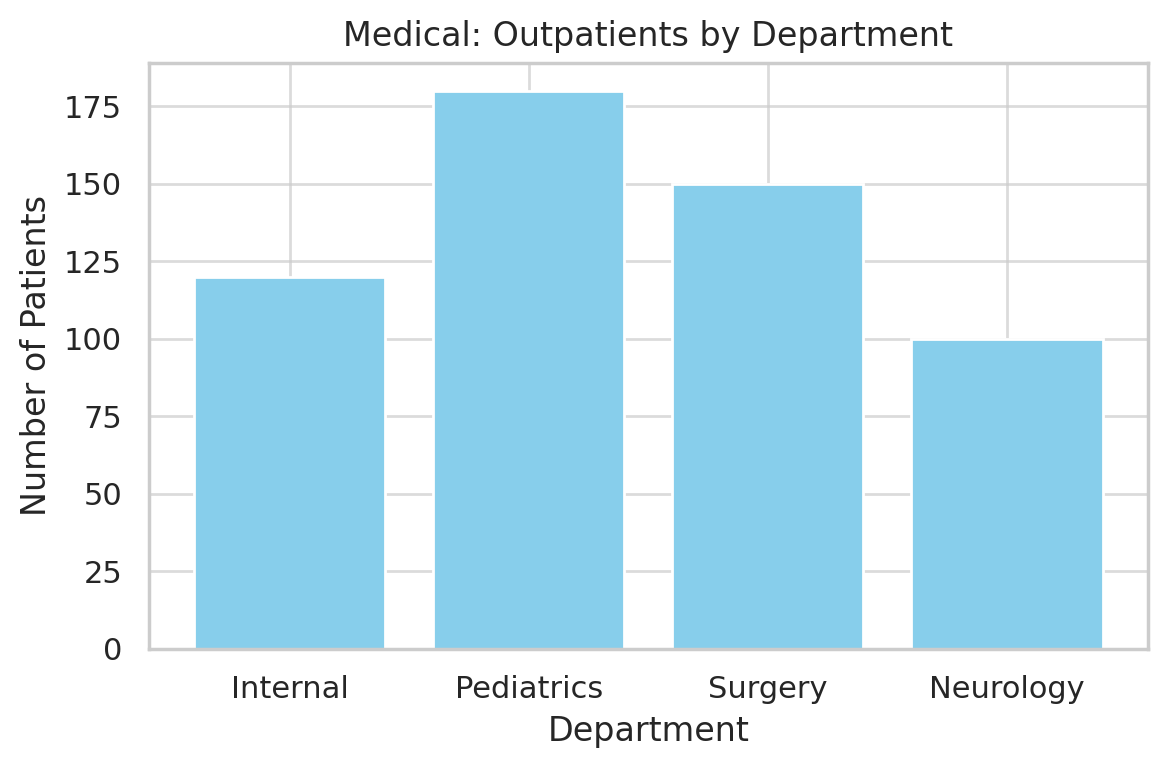

In [ ]:
from IPython import display
display.Image(img_path +"/"+ 'Bar-01.png', width = 500)

  **觀察與解釋**：兒科（Pediatrics）門診數量最高，顯示小兒科需求較高，資源配置上需特別留意。

- **電子商務領域：各類商品的月銷售筆數**  

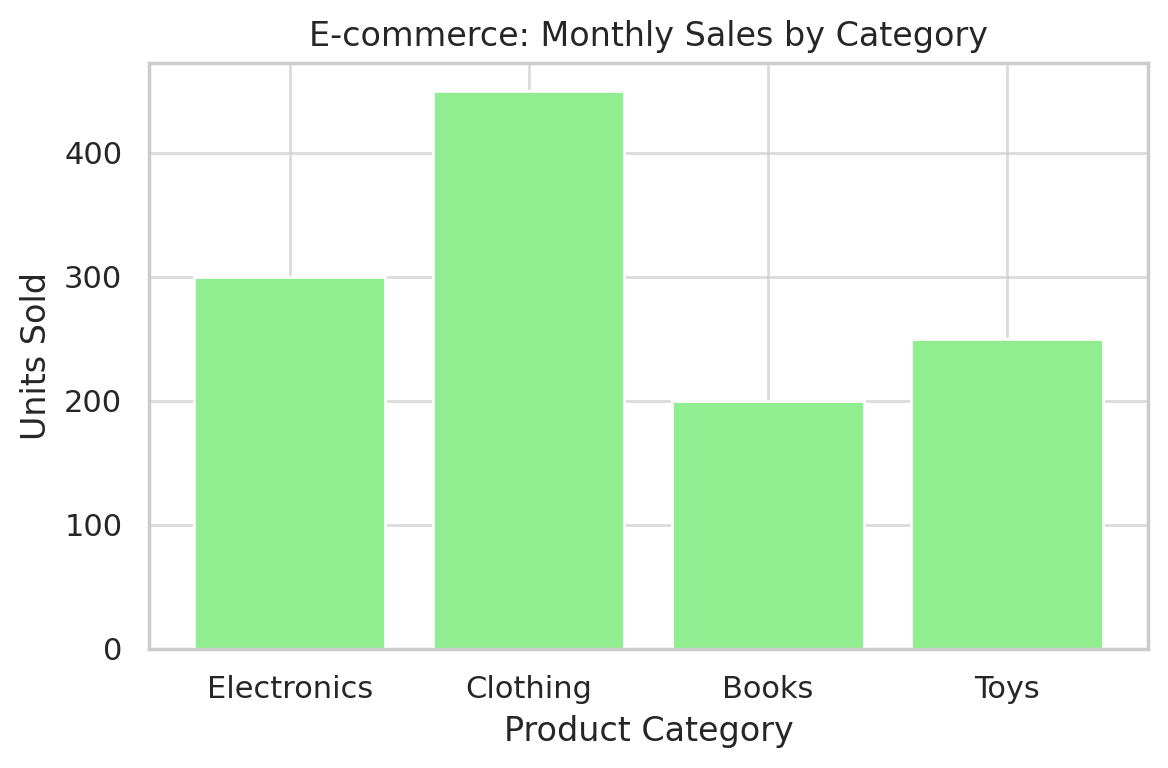

In [ ]:
from IPython import display
display.Image(img_path +"/"+'Bar-02.png', width = 500)

  **觀察與解釋**：Clothing 銷售表現最佳，Books 銷售較低，可作為行銷強化對象。

- **製造領域：各廠房製造單位產出數量**  
  


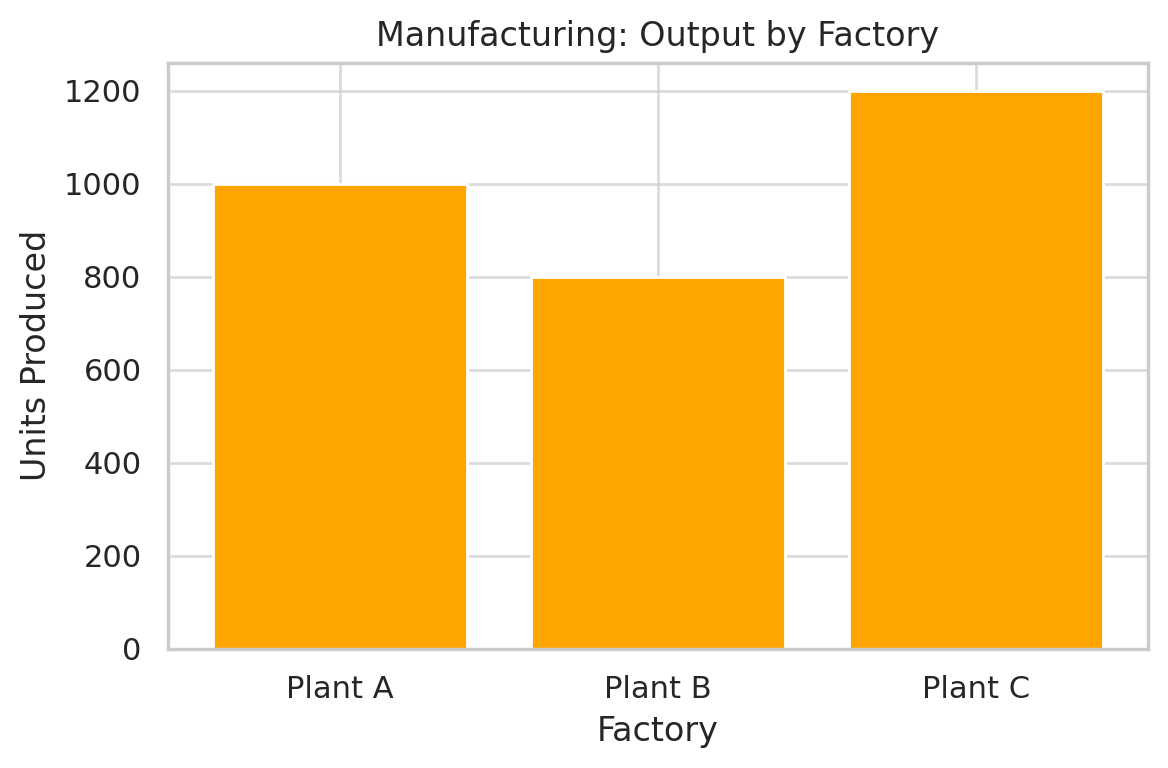

In [ ]:
from IPython import display
display.Image(img_path +"/"+'Bar-03.png', width = 500)

  **觀察與解釋**：Plant C 的產出最多，顯示產線效率較高；Plant B 可檢討是否需增能或改善流程。

### Try it!：5. 實際案例與圖表
院長想知道各科別門診量佔全院的比例，找出最需要增派人力的科別。

**程式要求**
1. 讀取 `datasets/weekly_outpatients_by_department.csv`，計算各科別佔總門診量的百分比（`Percent` 欄位）。
2. 印出統計表與佔比最高的科別名稱。
3. 以百分比繪製長條圖並標示數值。

### 6. 實作範例：醫學領域 - 各科別每週門診病人數視覺化（Bar Chart）

#### 📁 資料說明

| Department         | Weekly_Patients |
|--------------------|-----------------|
| Internal Medicine  | 230             |
| Pediatrics         | 310             |
| Orthopedics        | 180             |
| Neurology          | 150             |
| Dermatology        | 120             |




#### 💻 實作目標

透過 Seaborn 套件繪製「分類資料的長條圖」，並練習以下技能：

- 使用 `sns.barplot()` 畫出類別型資料的比較圖
- 設定圖表樣式（`sns.set`、`palette`）
- 在長條上加上數值標籤（`annotate`）
- 自訂圖表大小、文字旋轉、文字對齊等參數


          Department  Weekly_Patients
0  Internal Medicine              230
1         Pediatrics              310
2        Orthopedics              180
3          Neurology              150
4        Dermatology              120


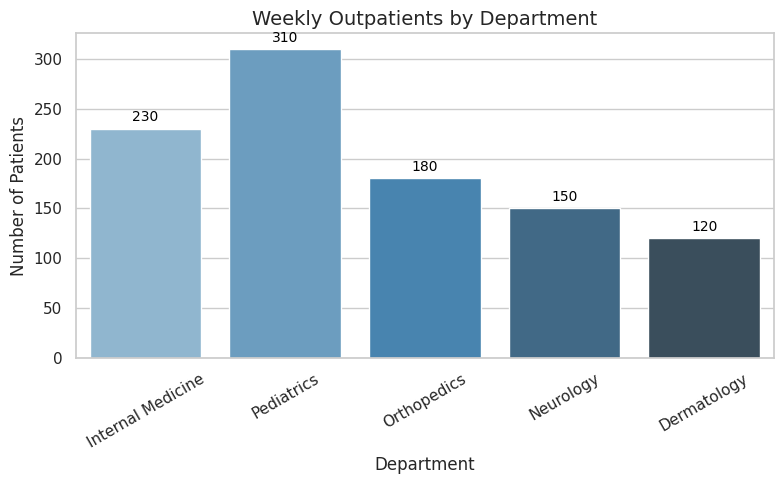

In [ ]:
# 匯入所需套件
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 讀取資料集（CSV 檔）
from pathlib import Path

data_file = "weekly_outpatients_by_department.csv"
df = pd.read_csv(path +"/"+data_file)

# 顯示資料的前幾列以確認內容
print(df.head())

# 設定 Seaborn 主題樣式
# 可選擇：'white', 'dark', 'whitegrid', 'darkgrid', 'ticks'
sns.set(style="whitegrid")

# 建立圖表區域，設定尺寸
plt.figure(figsize=(8, 5))

# 繪製長條圖
barplot = sns.barplot(
    data=df,
    x="Department",         # X-axis category
    y="Weekly_Patients",    # Y-axis value
    hue="Department",       # Use x variable as hue when applying a palette
    palette="Blues_d",
    legend=False
)

# 加上數值標籤於長條上方
for p in barplot.patches:
    barplot.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10, color='black',
        xytext=(0, 8),
        textcoords='offset points'
    )

# 設定圖表標題與軸標籤
plt.title("Weekly Outpatients by Department", fontsize=14)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# 旋轉 x 軸標籤，避免文字重疊
plt.xticks(rotation=30)

# 自動調整圖表元素避免重疊
plt.tight_layout()

# 顯示圖表
plt.show()

### Try it!：6. 實作範例：醫學領域 - 各科別每週門診病人數視覺化（Bar Chart）
仿照本節範例，用 Seaborn 完成同一張圖的美化版本。

**程式要求**
1. 讀取 `datasets/weekly_outpatients_by_department.csv`，依 `Weekly_Patients` 由高到低排序。
2. 使用 `sns.barplot` 繪製長條圖（`whitegrid` 樣式、`Blues_d` 調色盤）。
3. 在長條上方標示數值，x 軸標籤旋轉 0 度(橫式)。

#### 📌 額外補充參考表

**Seaborn 主題樣式（`sns.set(style=...)`）**

| 選項        | 說明                             |
|-------------|----------------------------------|
| `'white'`   | 簡潔無網格白底風格                |
| `'dark'`    | 黑底、對比強                     |
| `'whitegrid'` | 白底含格線（數據分析常用）     |
| `'darkgrid'` | 黑底含格線                      |
| `'ticks'`   | 簡潔樣式 + 刻度線               |

**顏色樣式（`palette=...`）**

| 類型        | 範例                                  |
|-------------|----------------------------------------|
| 預設風格    | `'deep'`, `'muted'`, `'bright'`, `'pastel'`, `'dark'`, `'colorblind'` |
| 顏色階調    | `'Blues'`, `'Greens'`, `'Reds'`, `'Purples'`（加 `_d` 為深色）        |
| 自訂顏色    | `['#4c72b0', '#55a868', '#c44e52']`（Hex 格式色碼）|

**對齊方式（`annotate()` 中的 `ha` / `va`）**

| 參數        | 可用值                             |
|-------------|------------------------------------|
| `ha` (水平) | `'left'`, `'center'`, `'right'`    |
| `va` (垂直) | `'top'`, `'center'`, `'bottom'`, `'baseline'` |


#### 📝 練習任務建議（設定參數的比較與應用）

1. **任務一：比較不同 `style` 對圖表整體風格的影響**  
   嘗試將 `sns.set(style="...")` 改為 `'white'`、`'darkgrid'`、`'ticks'` 等選項，觀察變化。

2. **任務二：更換 `palette` 並比較視覺效果**  
   使用 `'muted'`、`'pastel'`、`'Reds_d'` 等配色，觀察哪一種較易閱讀或呈現專業感。

3. **任務三：調整 `annotate()` 的 `ha` / `va`**  
   改變對齊方式，例如 `ha='right'`, `va='top'`，觀察數值標籤位置變化。

4. **任務四：修改 `figsize` 改變圖表版型**  
   嘗試 `(6, 6)`、`(10, 4)` 等圖表比例，了解版面對閱讀效果的影響。

5. **任務五：加入 hue 顯示分組資料（需擴充欄位）**  
   增加 `Region` 欄位，並在 `sns.barplot()` 中加入 `hue='Region'`，比較不同區域病患數。
